In [ ]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

from src.dataset import build_class_mapping, get_dataloaders
from src.preprocessing import get_device, get_transforms
from src.trainer import Trainer, build_optimizer, build_scheduler

# Пути
DATA_ROOT = Path("../data/raw")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Device
device = get_device() # mps

# Маппинг классов
class_to_idx, idx_to_class = build_class_mapping(DATA_ROOT / "train")
print(f"✅ Classes: {len(class_to_idx)}")
print(f"✅ Device:  {device}")

🖥️  Device: Apple Silicon MPS
✅ Classes: 38
✅ Device:  mps


In [2]:
# DataLoaders
dataloaders, datasets = get_dataloaders(
    class_to_idx=class_to_idx,
    data_root=DATA_ROOT,
    img_size=224,
    batch_size=32,
    num_workers=2,
)

print(f"\nDataset sizes:")
for phase, ds in datasets.items():
    print(f"  {phase:5s}: {len(ds):>7,} images")

  train →  70,295 images | 2196 batches | folder: train/
  val   →  17,572 images |  550 batches | folder: valid/
  test  →   1,742 images |   55 batches | folder: test/

Dataset sizes:
  train:  70,295 images
  val  :  17,572 images
  test :   1,742 images


In [3]:
# Функция для графиков
def plot_history(tracker, model_name: str):
    """Рисует loss и accuracy графики после обучения."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(tracker.history["train_loss"]) + 1)

    # Loss
    axes[0].plot(epochs, tracker.history["train_loss"],
                 label="Train", color="#3b8bd4", linewidth=2)
    axes[0].plot(epochs, tracker.history["val_loss"],
                 label="Val", color="#e8593c", linewidth=2)
    axes[0].axvline(x=tracker.best_epoch, color="gray",
                    linestyle="--", alpha=0.7, label=f"Best epoch {tracker.best_epoch}")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, tracker.history["train_acc"],
                 label="Train", color="#3b8bd4", linewidth=2)
    axes[1].plot(epochs, tracker.history["val_acc"],
                 label="Val", color="#e8593c", linewidth=2)
    axes[1].axvline(x=tracker.best_epoch, color="gray",
                    linestyle="--", alpha=0.7, label=f"Best epoch {tracker.best_epoch}")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"{model_name}  |  Best val_acc: {tracker.best_val_acc:.4f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{model_name}_history.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Best val_acc: {tracker.best_val_acc:.4f} (epoch {tracker.best_epoch})")

In [4]:
#  Эксперимент : CNN with scratch
from torchvision import models

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PlantCNN(nn.Module):
    def __init__(self, num_classes=38, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),   # 224→112
            ConvBlock(32,  64,  pool=True),   # 112→56
            ConvBlock(64,  128, pool=True),   # 56→28
            ConvBlock(128, 256, pool=True),   # 28→14
            ConvBlock(256, 512, pool=True),   # 14→7
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(128, num_classes),
        )
        # Kaiming инициализация
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


# Создаём модель
cnn_model = PlantCNN(num_classes=38).to(device)
total = sum(p.numel() for p in cnn_model.parameters())
print(f"🌿 PlantCNN — параметры: {total:,}")

# Loss с весами классов (дисбаланс 68/32)
class_weights = datasets["train"].get_class_weights().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = build_optimizer(cnn_model, "adam", lr=1e-3)
scheduler = build_scheduler(optimizer, "reduce_on_plateau")

# Trainer
cnn_trainer = Trainer(
    model=cnn_model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    model_name="plant_cnn",
    patience=5,
)

# Обучаем — начнём с 10 эпох чтобы посмотреть тренд
cnn_tracker = cnn_trainer.fit(epochs=1)

🌿 PlantCNN — параметры: 1,738,694

  Training: plant_cnn
  Epochs  : 1 | Device: mps



Epoch [  1/1] | Train loss: 2.4364  acc: 0.2962 | Val loss: 1.4931  acc: 0.5621 | 325.8s ⭐

✅ Training complete!
   Best val_acc : 0.5621 (epoch 1)


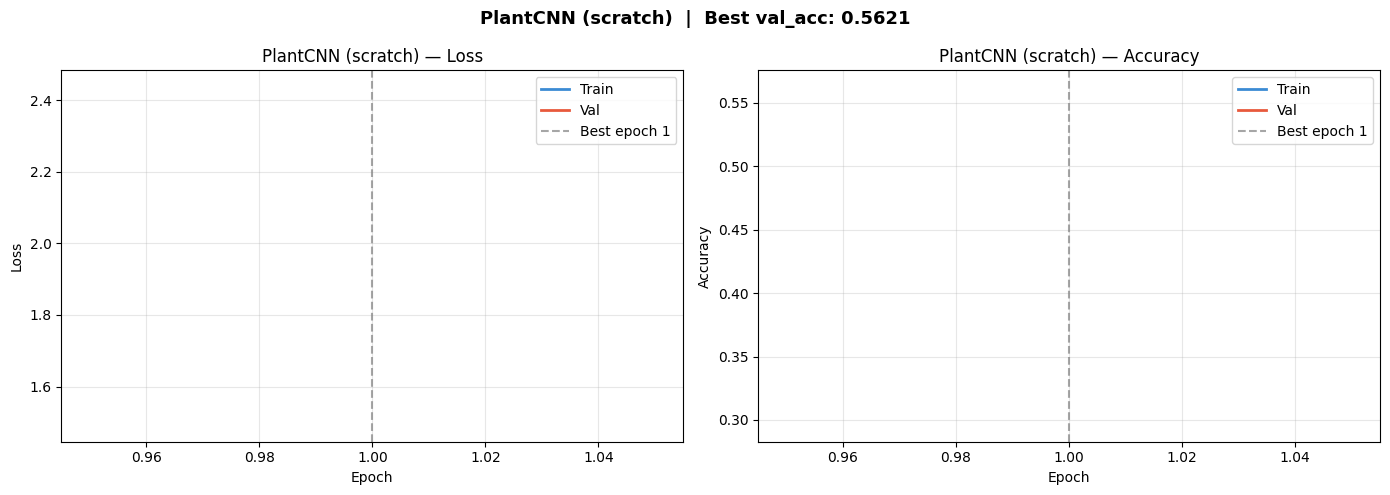

✅ Best val_acc: 0.5621 (epoch 1)



📊 TEST Results:
   Loss     : 1.4918
   Accuracy : 0.5563 (55.63%)


(1.4917966492824795, 0.5562571756601608)

In [5]:
plot_history(cnn_tracker, "PlantCNN (scratch)")
cnn_trainer.evaluate("test")

In [ ]:
# ЭКСПЕРИМЕНТ 2: EfficientNet-B0
# Transfer Learning — Фаза 1 (frozen backbone)
backbone = models.efficientnet_b0(weights="DEFAULT")
in_features = backbone.classifier[1].in_features
backbone.classifier = nn.Identity()

# Замораживаем backbone
for param in backbone.parameters():
    param.requires_grad = False

# Наш head
head = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(512, 38),
)

class EfficientNetPlant(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head     = head

    def forward(self, x):
        return self.head(self.backbone(x))

    def unfreeze(self, n_layers=3):
        children = list(self.backbone.children())
        for child in children[-n_layers:]:
            for p in child.parameters():
                p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"🔓 Unfroze {n_layers} layers — trainable: {trainable:,}")


eff_model = EfficientNetPlant(backbone, head).to(device)
trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in eff_model.parameters())
print(f"🌿 EfficientNet-B0")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,} (head only)")

# Фаза 1 — обучаем только head
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = build_optimizer(eff_model, "adamw", lr=1e-3)
scheduler = build_scheduler(optimizer, "cosine", epochs=10)

eff_trainer = Trainer(
    model=eff_model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    model_name="efficientnet_b0_phase1",
    patience=5,
)

print("\n📌 Фаза 1: обучаем только head (backbone заморожен)")
eff_tracker_p1 = eff_trainer.fit(epochs=1)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/shopangaliy/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 7.47MB/s]


🌿 EfficientNet-B0
   Total params    : 4,682,914
   Trainable params: 675,366 (head only)

📌 Фаза 1: обучаем только head (backbone заморожен)

  Training: efficientnet_b0_phase1
  Epochs  : 1 | Device: mps



Epoch [  1/1] | Train loss: 0.6923  acc: 0.7931 | Val loss: 0.1893  acc: 0.9381 | 271.7s ⭐

✅ Training complete!
   Best val_acc : 0.9381 (epoch 1)


In [ ]:

# ФАЗА 2: Fine-tuning — размораживаем backbone
print("📌 Фаза 2: fine-tuning (размораживаем backbone)")

eff_model.unfreeze(n_layers=3)

# Меньший lr для fine-tuning — не сломать pretrained веса
optimizer2 = build_optimizer(eff_model, "adamw", lr=1e-4)
scheduler2 = build_scheduler(optimizer2, "cosine", epochs=10)

eff_trainer2 = Trainer(
    model=eff_model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer2,
    scheduler=scheduler2,
    device=device,
    model_name="efficientnet_b0_phase2",
    patience=5,
)

eff_tracker_p2 = eff_trainer2.fit(epochs=1)

📌 Фаза 2: fine-tuning (размораживаем backbone)
🔓 Unfroze 3 layers — trainable: 4,682,914

  Training: efficientnet_b0_phase2
  Epochs  : 11 | Device: mps



Epoch [  1/11] | Train loss: 0.1560  acc: 0.9493 | Val loss: 0.0286  acc: 0.9906 | 937.6s ⭐


  train:  41%|██▍   | 899/2196 [07:21<08:15,  2.62it/s, loss=0.0209, acc=1.0000]

: 

In [ ]:
plot_history(eff_tracker_p1, "EfficientNet-B0 Phase1")
plot_history(eff_tracker_p2, "EfficientNet-B0 Phase2")
eff_trainer2.evaluate("test")

In [ ]:
print("📊 СРАВНЕНИЕ МОДЕЛЕЙ\n")

results = {
    "PlantCNN (scratch)": {
        "acc": cnn_tracker.best_val_acc,
        "f1": cnn_tracker.best_val_f1,
        "precision": cnn_tracker.best_val_precision,
        "recall": cnn_tracker.best_val_recall,
        "loss": cnn_tracker.best_val_loss,
        "time": cnn_tracker.training_time
    },
    
    "EfficientNet-B0 Phase1": {
        "acc": eff_tracker_p1.best_val_acc,
        "f1": eff_tracker_p1.best_val_f1,
        "precision": eff_tracker_p1.best_val_precision,
        "recall": eff_tracker_p1.best_val_recall,
        "loss": eff_tracker_p1.best_val_loss,
        "time": eff_tracker_p1.training_time
    },
    
    "EfficientNet-B0 Phase2": {
        "acc": eff_tracker_p2.best_val_acc,
        "f1": eff_tracker_p2.best_val_f1,
        "precision": eff_tracker_p2.best_val_precision,
        "recall": eff_tracker_p2.best_val_recall,
        "loss": eff_tracker_p2.best_val_loss,
        "time": eff_tracker_p2.training_time
    }
}

for name, metrics in sorted(results.items(), key=lambda x: x[1]["acc"], reverse=True):
    acc = metrics["acc"]
    bar = "█" * int(acc * 40)

    print(f"{name:<30}")
    print(f"  Accuracy  : {metrics['acc']:.4f} {bar}")
    print(f"  F1-score  : {metrics['f1']:.4f}")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  Val Loss  : {metrics['loss']:.4f}")
    print(f"  Time (s)  : {metrics['time']:.1f}")
    print("-" * 50)